In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

#Upload file from PC
uploaded = files.upload()


Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [4]:
#Load CSV into DataFrame
t_df = pd.read_csv('Titanic-Dataset.csv')


Data Inspection

In [5]:
t_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
t_df.shape

(891, 12)

In [7]:
t_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
t_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
t_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Data Handling

In [10]:
t_df['Cabin'].isnull().mean()*100

np.float64(77.10437710437711)

In [11]:
t_df.drop(columns=['Cabin'],inplace=True)

In [12]:
#Embark by where many people go to which city
t_df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [13]:
t_df['Embarked'].fillna('S',inplace=True)

/tmp/ipython-input-4018115316.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  t_df['Embarked'].fillna('S',inplace=True)


In [14]:
# randomly generate age values in the range of mean-std and mean+std
t_age=np.random.randint(t_df['Age'].mean()-t_df['Age'].std(),t_df['Age'].mean()+t_df['Age'].std(),177)

In [15]:
t_age

array([18, 15, 40, 32, 27, 34, 16, 36, 35, 32, 24, 41, 19, 24, 43, 16, 38,
       32, 20, 28, 25, 19, 30, 36, 35, 30, 37, 30, 17, 34, 20, 21, 26, 39,
       35, 30, 18, 36, 40, 19, 28, 30, 35, 35, 35, 21, 42, 41, 35, 26, 43,
       42, 43, 29, 25, 34, 40, 27, 16, 25, 42, 28, 26, 30, 35, 28, 40, 17,
       32, 30, 19, 41, 42, 32, 24, 35, 32, 29, 40, 27, 33, 35, 29, 41, 22,
       23, 30, 28, 40, 15, 30, 32, 36, 34, 25, 15, 17, 28, 15, 41, 17, 41,
       23, 39, 22, 22, 40, 32, 35, 29, 21, 23, 25, 42, 29, 21, 42, 24, 19,
       38, 20, 25, 28, 36, 29, 15, 18, 22, 22, 41, 21, 22, 36, 31, 16, 18,
       37, 17, 21, 36, 23, 40, 23, 15, 33, 33, 38, 40, 31, 32, 39, 42, 43,
       35, 29, 17, 15, 28, 39, 43, 23, 35, 17, 38, 40, 42, 17, 31, 29, 33,
       17, 16, 19, 34, 34, 26, 31])

In [16]:
t_df['Age'][t_df['Age'].isnull()]=t_age

/tmp/ipython-input-3710107104.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  t_df['Age'][t_df['Age'].isnull()]=t_age
/tmp/ipython-input-3710107104.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [17]:
t_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


EDA

In [19]:
death_percentage=round((t_df['Survived'].value_counts().values[0]/89)*100)
print('Out of 891 {} people in the accident'.format(death_percentage))

Out of 891 617 people in the accident


<Axes: xlabel='Survived'>

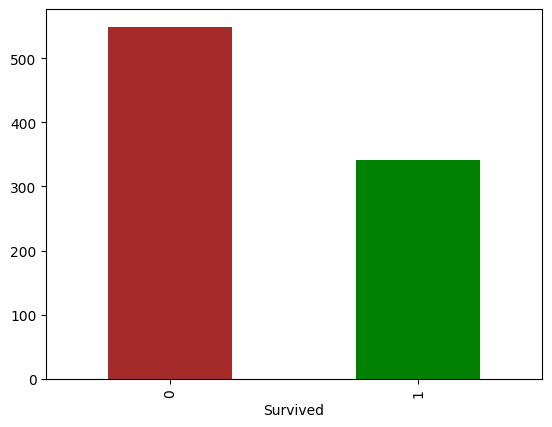

In [24]:
t_df['Survived'].value_counts().plot(kind='bar', color=['brown', 'green'])

In [25]:
t_df.groupby(['Pclass'])['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


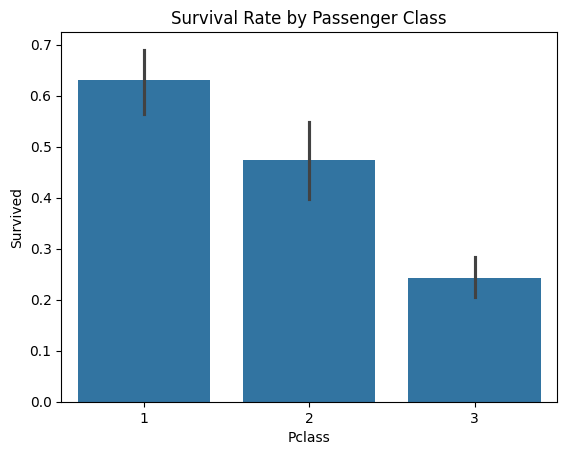

In [33]:
sns.barplot(x='Pclass', y='Survived', data=t_df)
plt.title('Survival Rate by Passenger Class')
plt.show()

Pclass has a mathematical coorelation with survived column as higher class have higher percentage of survival

In [28]:
t_df.groupby(['Sex'])['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


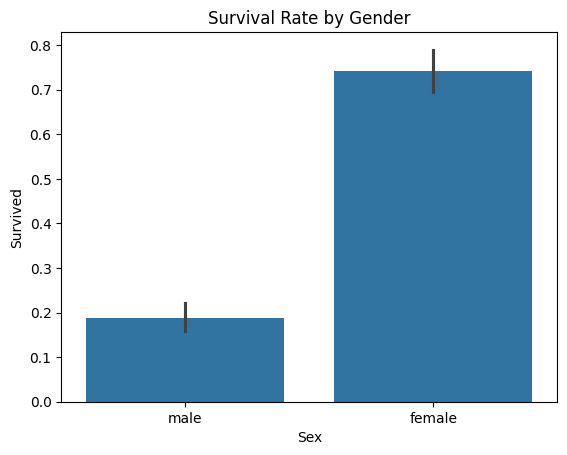

In [34]:
sns.barplot(x='Sex', y='Survived', data=t_df)
plt.title('Survival Rate by Gender')
plt.show()


Females are more survived and survival depend upon it

In [35]:
t_df.groupby(['Embarked'])['Survived'].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.339009


In [36]:
t_df['Age'].skew()

np.float64(0.38675699651716317)

/tmp/ipython-input-3620970387.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(t_df['Age'][t_df['Survived']==0])
/tmp/ipython-input-3620970387.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(t_df['Age'][t_df['Survived']==1])


<Axes: xlabel='Age', ylabel='Density'>

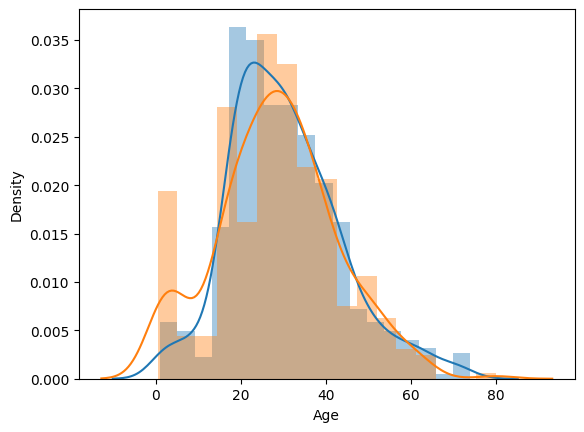

In [37]:
sns.distplot(t_df['Age'][t_df['Survived']==0])
sns.distplot(t_df['Age'][t_df['Survived']==1])

Blue for Elders and children are less and mid age are far more in the data and children and elders are preferred to save mid age pepole died more

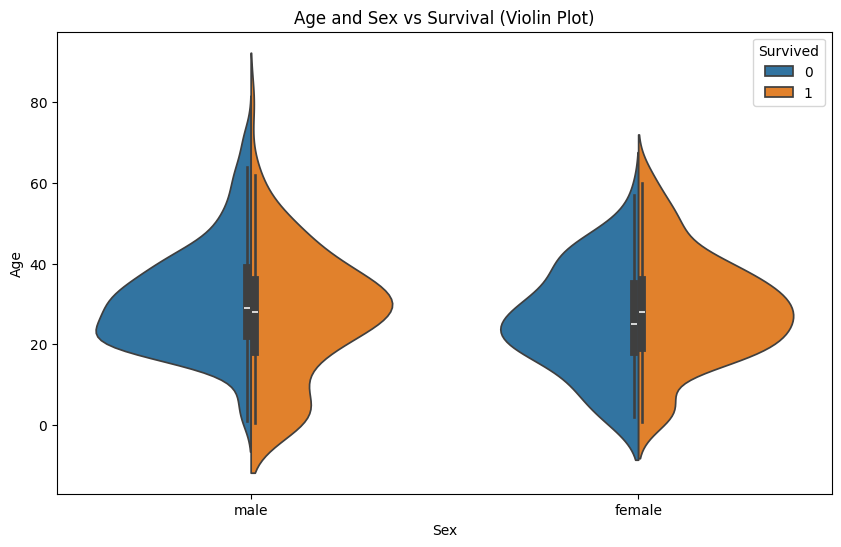

In [38]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Sex', y='Age', hue='Survived', data=t_df, split=True)
plt.title('Age and Sex vs Survival (Violin Plot)')
plt.show()


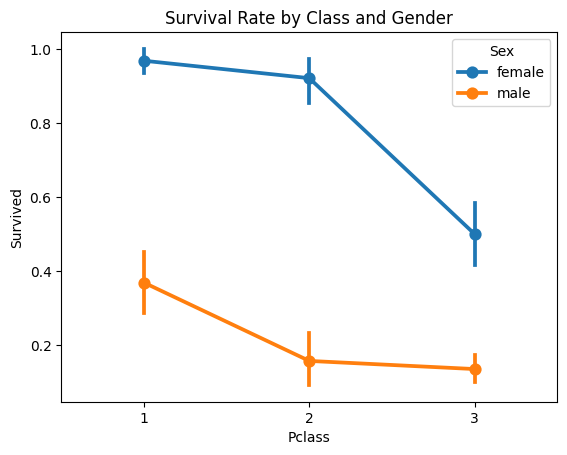

In [39]:
sns.pointplot(x='Pclass', y='Survived', hue='Sex', data=t_df)
plt.title('Survival Rate by Class and Gender')
plt.show()

/tmp/ipython-input-3902191386.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(t_df['Fare'][t_df['Survived']==0])
/tmp/ipython-input-3902191386.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(t_df['Fare'][t_df['Survived']==1])


<Axes: xlabel='Fare', ylabel='Density'>

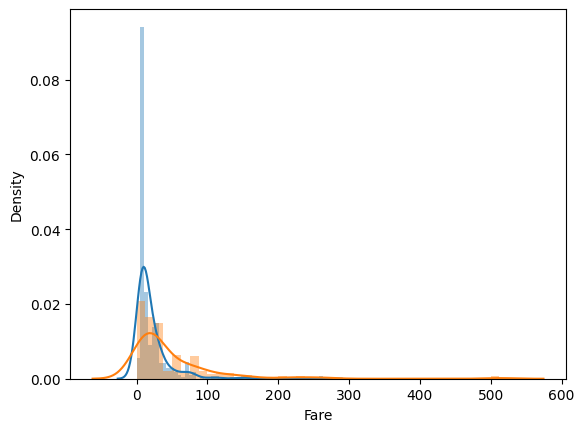

In [40]:
sns.distplot(t_df['Fare'][t_df['Survived']==0])
sns.distplot(t_df['Fare'][t_df['Survived']==1])

More fare have higher chances to survived and low fare people died more

Feature Engineering

In [44]:
#name title
t_df['Title'] = t_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-4167487390.py:2: SyntaxWarning: invalid escape sequence '\.'
  t_df['Title'] = t_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [45]:
# View the most common titles
print(t_df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [46]:
# Grouping rare titles
t_df['Title'] =t_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')


In [47]:

t_df['Title'] = t_df['Title'].replace('Mlle', 'Miss')
t_df['Title'] =t_df['Title'].replace('Ms', 'Miss')
t_df['Title'] = t_df['Title'].replace('Mme', 'Mrs')


In [48]:
t_df['Title'].value_counts()

,count
Title,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,23


In [49]:
t_df[['Title', 'Survived']].groupby(['Title']).mean()

,Survived
Title,
Master,0.575000
Miss,0.702703
Mr,0.156673
Mrs,0.793651
Rare,0.347826


In [50]:
t_df['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [51]:
t_df['Parch'].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


In [52]:
#Parch and sipsp combined into one column as family column
t_df['Family']=t_df['SibSp']+t_df['Parch'] +1

In [53]:
t_df['Family'].value_counts()

,count
Family,
1,537
2,161
3,102
4,29
6,22
5,15
7,12
11,7
8,6


In [54]:
t_df.groupby(['Family'])['Survived'].mean()

,Survived
Family,
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


Alone have less chances to survive, as no of family member increases chances of survival increases then again chances drop as family members increased to 11 or 8

In [55]:
def cal(number):
  if number==1:
    return 'Alone'
  elif number>1 and number<5:
    return 'Medium'
  else:
    return 'Large'

In [56]:
t_df['Family_Size']=t_df['Family'].apply(cal)

In [57]:
t_df['Family_Size']

,Family_Size
0,Medium
1,Medium
2,Alone
3,Medium
4,Alone
...,...
886,Alone
887,Alone
888,Medium
889,Alone


In [68]:
t_df.shape

(891, 8)

In [67]:
t_df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title',
       'Family_Size'],
      dtype='object')

In [59]:
passengerId=t_df['PassengerId'].values

In [62]:
t_df.drop(columns=['PassengerId','Name','SibSp','Parch','Ticket','Family'],inplace=True)

In [66]:
t_df.drop(columns=['Ticket_Prefix'],inplace=True)

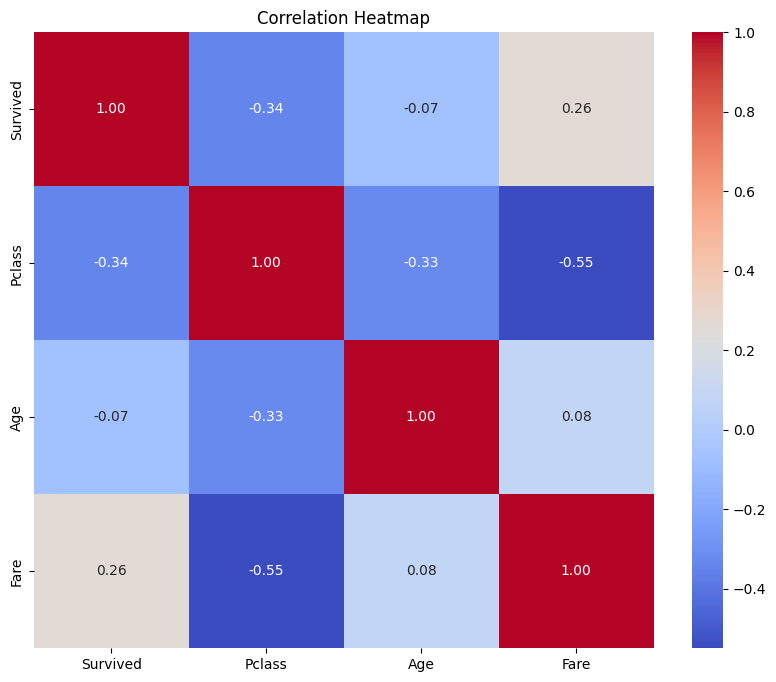

In [69]:
# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = t_df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Encoding (Turning Words into Numbers)

In [70]:
df_final = pd.get_dummies(t_df, columns=['Sex', 'Embarked', 'Title','Family_Size'], drop_first=True)



Scaling (Balancing the Numbers)

In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# We only scale numerical columns like Age and Fare
df_final[['Age', 'Fare']] = scaler.fit_transform(df_final[['Age', 'Fare']])

Training the Model

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [74]:
# Define Features (X) and Target (y)
X = df_final.drop('Survived', axis=1)
y = df_final['Survived']


In [75]:
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [80]:
X_train

,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Family_Size_Large,Family_Size_Medium
331,1,1.172119,-0.074583,True,False,True,False,True,False,False,False,False
733,2,-0.491657,-0.386671,True,False,True,False,True,False,False,False,False
382,3,0.173854,-0.488854,True,False,True,False,True,False,False,False,False
704,3,-0.269820,-0.490280,True,False,True,False,True,False,False,False,True
813,3,-1.748732,-0.018709,False,False,True,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
106,3,-0.639548,-0.494391,False,False,True,True,False,False,False,False,False
270,1,0.987255,-0.024246,True,False,True,False,True,False,False,False,False
860,3,0.839364,-0.364355,True,False,True,False,True,False,False,False,True
435,1,-1.157168,1.767741,False,False,True,True,False,False,False,False,True


In [76]:
# Initialize and train
model = RandomForestClassifier(n_estimators=100, random_state=42)


In [77]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Evaluation (How did we do?)

In [78]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Final Accuracy: 83.80%

--- Confusion Matrix ---
[[91 14]
 [15 59]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       105
           1       0.81      0.80      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



Final Check: Feature Importance

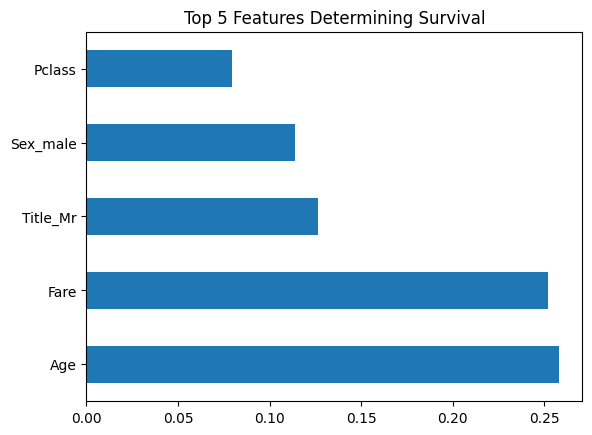

In [79]:
# Visualize which features were most important
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh')
plt.title('Top 5 Features Determining Survival')
plt.show()